In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
dados_vendas = {
    'mes': [
      'Janeiro', 'Fevereiro', 'Março', 'Abril', 'Maio', 'Junho',  'Julho', 'Agosto', 'Setembro', 'Outubro', 'Novembro', 'Dezembro'
    ],
    'vendas': [
       2000, 2200, 2300, 2500, 2600, 2700,
       2800, 2900, 3000, 3100, 3200, 3300
    ]
}

In [4]:
df_vendas = pd.DataFrame(dados_vendas)
print(df_vendas)

          mes  vendas
0     Janeiro    2000
1   Fevereiro    2200
2       Março    2300
3       Abril    2500
4        Maio    2600
5       Junho    2700
6       Julho    2800
7      Agosto    2900
8    Setembro    3000
9     Outubro    3100
10   Novembro    3200
11   Dezembro    3300


In [5]:
df_vendas.info()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   mes     12 non-null     str  
 1   vendas  12 non-null     int64
dtypes: int64(1), str(1)
memory usage: 324.0 bytes


In [ ]:
# Mapear os meses para números
df_vendas['mes_num'] = df_vendas['mes'].map({
    'Janeiro': 1, 'Fevereiro': 2, 'Março': 3, 'Abril': 4,
    'Maio': 5, 'Junho': 6, 'Julho': 7, 'Agosto': 8,
    'Setembro': 9, 'Outubro': 10, 'Novembro': 11, 'Dezembro': 12
})
print(df_vendas)

          mes  vendas  mes_num
0     Janeiro    2000        1
1   Fevereiro    2200        2
2       Março    2300        3
3       Abril    2500        4
4        Maio    2600        5
5       Junho    2700        6
6       Julho    2800        7
7      Agosto    2900        8
8    Setembro    3000        9
9     Outubro    3100       10
10   Novembro    3200       11
11   Dezembro    3300       12


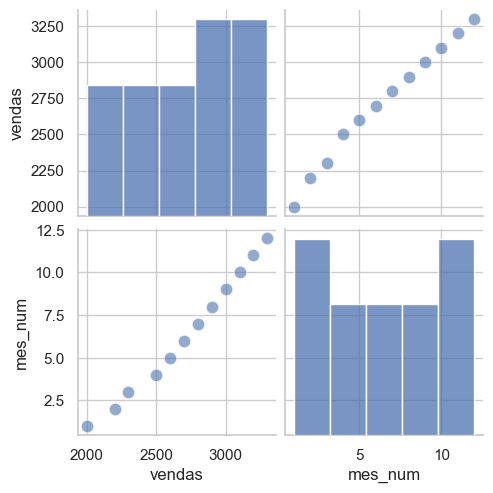

In [52]:
# Cria a matriz de dispersão com histogramas na diagonal
sns.pairplot(df_vendas, diag_kind='hist', plot_kws={'alpha': 0.6, 's': 80})
plt.show()

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

In [61]:
# Preparar os dados para o modelo
df_modelo = df_vendas.drop(columns=['mes'])
X = df_modelo[['mes_num']]
y = df_modelo['vendas']

In [41]:
# Dividir conjunto entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=51)

In [42]:
len(X_train), len(X_test)

(8, 4)

In [ ]:
# Treinar o algoritmo de regressão linear
modelo = LinearRegression().fit(X_train, y_train)

In [ ]:
# Gerar predições do conjunto de testes com base no modelo treinado
y_pred = modelo.predict(X_test)

In [45]:
# Equação da reta - regressão linear
# y = ax + b
modelo.coef_, modelo.intercept_

(array([114.16666667]), np.float64(1963.3333333333333))

In [63]:
# Validar o modelo - r2 score e MAE

In [ ]:
# r2 score - (conjunto de treinamento do modelo)
modelo.score(X_train, y_train)

0.990709949854843

In [53]:
# r2 score - (conjunto de teste do modelo)
modelo.score(X_test, y_test)

0.9631440781440782

In [54]:
# r2 score - testes
r2_score(y_test, y_pred)

0.9631440781440782

In [55]:
# MAE (Mean Absolute Error)
mean_absolute_error(y_test, y_pred)

36.66666666666663

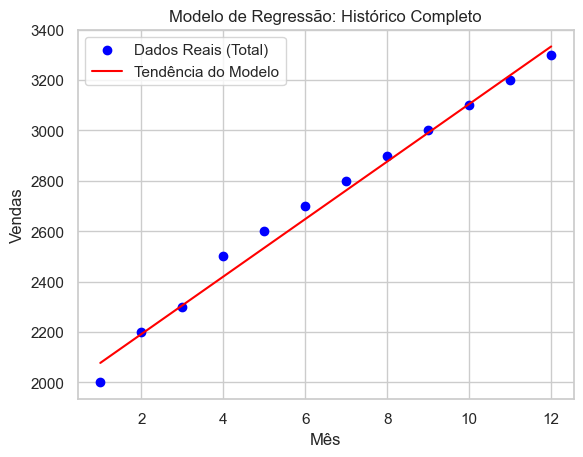

In [ ]:
# Plotar os dados reais (12 meses)
plt.scatter(X, y, color='blue', label='Dados Reais (Total)')

# Plotar a reta baseada no intervalo (do mês 1 ao 12)
plt.plot(X, modelo.predict(X), color='red', label='Tendência do Modelo')

plt.title('Modelo de Regressão: Histórico Completo')
plt.xlabel('Mês')
plt.ylabel('Vendas')
plt.legend()
plt.show()

In [ ]:
entrada_dezembro = pd.DataFrame([[12]], columns=['mes_num'])

predicao_dezembro = modelo.predict(entrada_dezembro)

print(f"A previsão de vendas para Dezembro é: R$ {predicao_dezembro[0]:.2f}")

A previsão de vendas para Dezembro é: R$ 3333.33
